In [7]:
import pandas as pd
import numpy as np
from nilearn.glm.first_level import make_first_level_design_matrix
import matplotlib.pyplot as plt
from nilearn.plotting import plot_design_matrix, plot_anat
from nilearn.glm.first_level import FirstLevelModel
import nibabel as nib

from nilearn.plotting import plot_contrast_matrix
import nibabel as nib
import os

from nilearn.plotting import plot_stat_map
from nilearn.image import mean_img

In [12]:
# experimental design -- upload the data
behav_file = '/Users/barbaragrosjean/Desktop/CHUV/PreddiBrains/data/PB_001/bahav/NC_001Block1.csv'
behav = pd.read_csv(behav_file).drop(columns = ['Unnamed: 0'])

# intake date starting - ending time 
intake = pd.read_csv('/Users/barbaragrosjean/Desktop/CHUV/PreddiBrains/data/PB_001/bahav/PBNC001_IntakeData.csv')

# image to have the number of time point
img = nib.load('/Users/barbaragrosjean/Desktop/CHUV/PreddiBrains/data/PB_001/preproc/tedana_PB_001_run1.nii.gz')


In [115]:
behav['trial_type'] = behav['Condition'].map({0 : 'inconscient', 1:'conscient'}) + '_' + behav['Bias'].apply(lambda x : str(round(x, 2))) 
behav['trial_type'] = behav['Condition']

In [121]:
run = 1
img = nib.load(f'/Users/barbaragrosjean/Desktop/CHUV/PreddiBrains/data/PB_001/preproc/tedana_PB_001_run{run}.nii.gz')

TR = img.header.get_zooms()[3]
n_scans = img.shape[3]
frame_times = np.arange(n_scans) * TR

# take time of the run and split 
start_time = intake[f'StartTime{run}'].values[0]
end_time = intake[f'EndTime{run}'].values[0]

events = behav[['StimOnset', 'trial_type', 'Bias']].fillna(value=0).rename(columns = {'StimOnset' : 'onset'})
events = events[events['onset'] >= start_time][events['onset'] <= end_time ]
events["duration"] = 1.0

design_matrix = make_first_level_design_matrix(
    frame_times,
    events,
)

/opt/anaconda3/envs/imaging/lib/python3.12/site-packages/nilearn/glm/first_level/experimental_paradigm.py:177: UserWarning: The following unexpected columns in events data will be ignored: Bias
  warnings.warn(


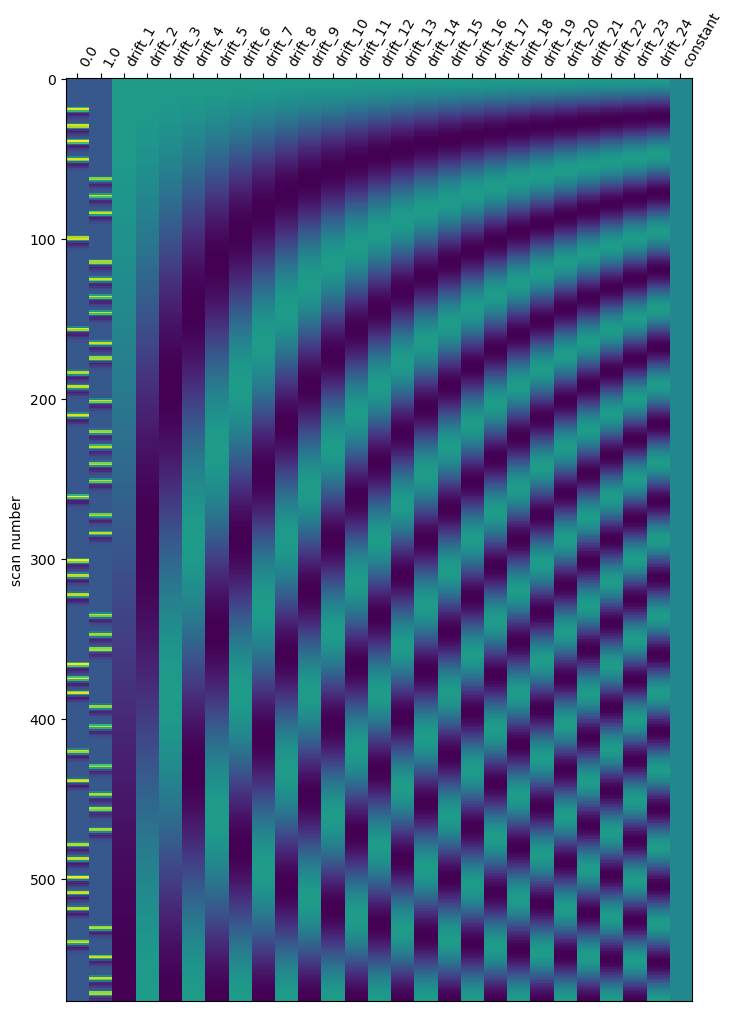

In [122]:

plot_design_matrix(design_matrix)
plt.show()

In [108]:
design_matrix.columns 

Index(['conscient_-0.3', 'conscient_-0.5', 'conscient_-0.7', 'conscient_-0.9',
       'conscient_0.0', 'conscient_0.3', 'conscient_0.5', 'conscient_0.7',
       'conscient_0.9', 'conscient_nan', 'inconscient_-0.3',
       'inconscient_-0.5', 'inconscient_-0.7', 'inconscient_-0.9',
       'inconscient_0.0', 'inconscient_0.5', 'inconscient_0.7',
       'inconscient_0.9', 'inconscient_nan', 'drift_1', 'drift_2', 'constant'],
      dtype='object')

In [ ]:
# Contrast 1
Conscious_percept = np.array([1 if 'conscient' in n else 0 for n in design_matrix.columns])
Inconscious_percept = np.array([1 if 'inconscient' in n else 0 for n in design_matrix.columns])
bais = np.array([0.3, 0.5, 0.7, 0.9, 1, 0.3, 0.5, 0.7, 0.9, 0, 0.3, 0.5, 0.7, 0.9, 1, 0.3, 0.5, 0.7, 0.9, 0, 0, 0 ])

[0.3,
 0.5,
 0.7,
 0.9,
 1,
 0.3,
 0.5,
 0.7,
 0.9,
 0,
 0.3,
 0.5,
 0.7,
 0.9,
 1,
 0.3,
 0.5,
 0.7,
 0.9]

__________________________